## Plot For JudgeBench

### Round Number Distribution

In [1]:
from multi_llm_debate.analysis.utils import count_files_per_directory, combine_plots
from multi_llm_debate.analysis.plot_correct_rate_distribution import (
    plot_file_count_distribution,
)
from matplotlib import pyplot as plt
from typing import Tuple


def main(model_dir_path: str) -> Tuple[plt.Figure, plt.Axes]:
    """Main function to analyze and visualize file count distribution.

    Args:
        model_dir_path: Path to the model directory containing data.

    Returns:
        A tuple containing the figure and axes of the plot.
    """
    print(f"Analyzing files in: {model_dir_path}")

    # Get file count distribution
    distribution = count_files_per_directory(model_dir_path)

    # Display summary
    # if distribution:
    #     print("\nFile count distribution across directories:")
    #     print(f"{'Files':<10} {'Directories':>12}")
    #     print("-" * 22)
    #     for count, num_dirs in sorted(distribution.items()):
    #         print(f"{count:<10} {num_dirs:>12}")

    #     total_dirs = sum(distribution.values())
    #     print(f"\nTotal directories analyzed: {total_dirs}")
    #     print(f"Average files per directory: {sum(k*v for k,v in distribution.items())/total_dirs:.2f}")
    # else:
    #     print("No directory data found.")
    model_config = model_dir_path.split("/")[-1]
    task_name = "Judge Bench"
    # Create visualization
    figure, ax = plot_file_count_distribution(
        distribution=distribution,
        model_config=model_config,
        task_name=task_name,
    )
    return figure, ax


if __name__ == "__main__":
    fig1, ax1 = main("../data/big_bench_pruning/gemini-2_0-flash-001(11)")

    plt.tight_layout()
    plt.show()  # Display the combined plot

KeyboardInterrupt: 

## Accuracy by Round

### JudgeBench

Loaded GPT and Claude splits from local paths.


Round 2: 100%|██████████| 620/620 [00:00<00:00, 2479.20task/s]


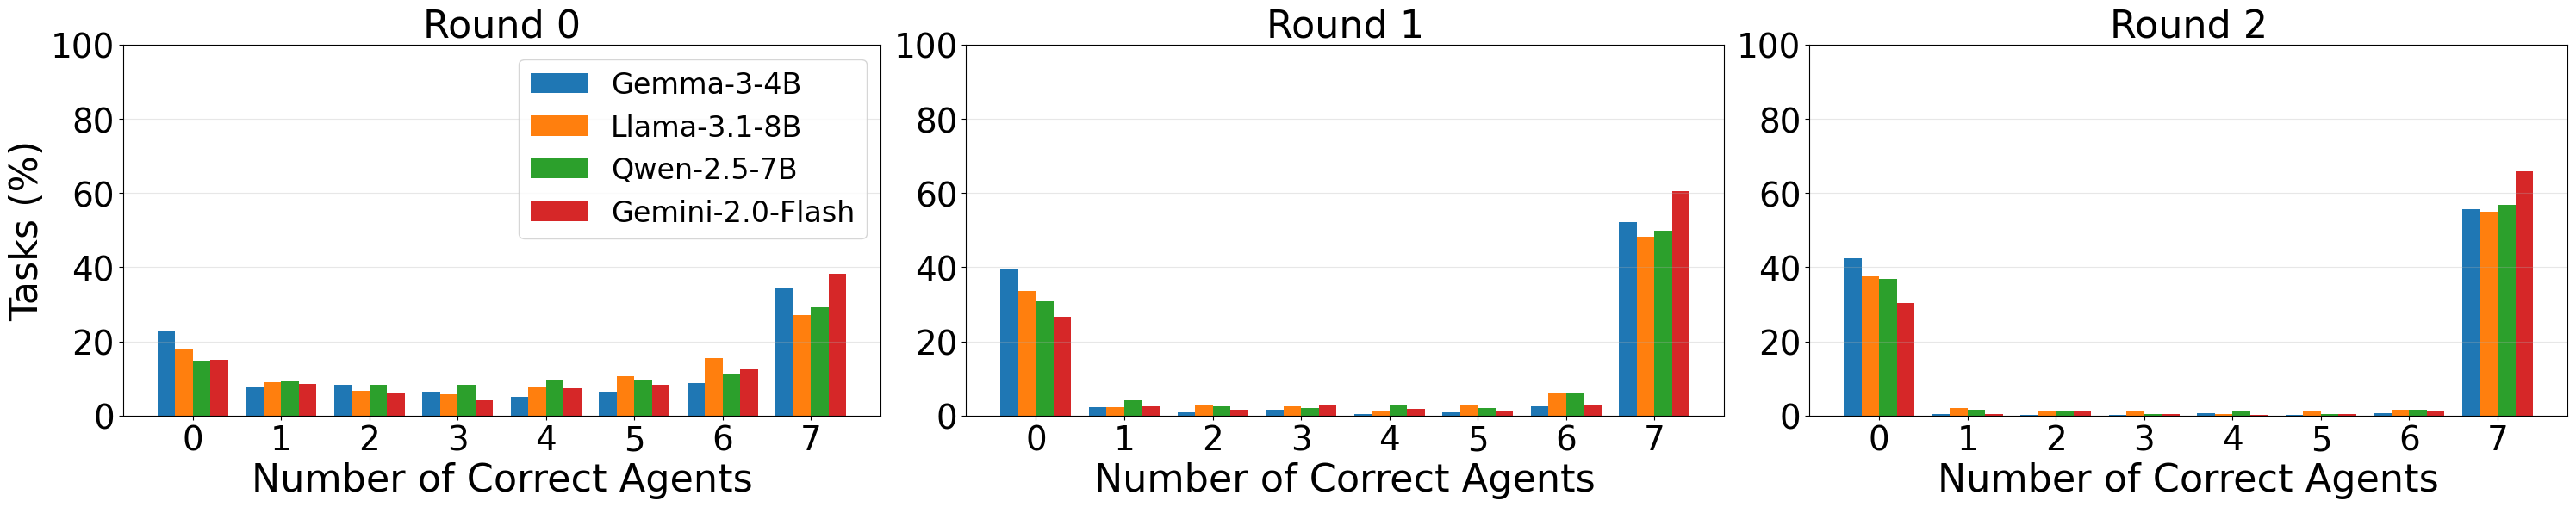

In [1]:
if __name__ == "__main__":
    import logging
    from pathlib import Path

    from multi_llm_debate.run.judge_bench.utils import (
        compare_judge_bench_response,
        extract_caption_a_b_answer,
        load_judge_bench_dataset,
    )
    from multi_llm_debate.analysis.plot_correct_rate_distribution import (
        combine_correct_rate_plots,
    )

    logger = logging.getLogger(__name__)
    logger.setLevel(logging.ERROR)

    df = load_judge_bench_dataset(base_path="../")
    OUTPUT_DIR = Path("../output/visualizations/judge_bench")
    task_name = "Judge Bench"

    model_dirs = [
        Path("../data/judge_bench/gemma-3-4b-it(7)"),
        Path("../data/judge_bench/Llama-3_1-8B-Instruct(7)"),
        Path("../data/judge_bench/Qwen2_5-7B-Instruct(7)"),
        Path("../data/judge_bench/gemini-2_0-flash-001(7)"),
    ]

    model_configs = [
        "Gemma-3-4B",
        "Llama-3.1-8B",
        "Qwen-2.5-7B",
        "Gemini-2.0-Flash",
    ]
    extract_func = extract_caption_a_b_answer
    compare_func = compare_judge_bench_response
    max_rounds = 3
    rows = 1
    columns = 3
    show_plot = True
    combined_title = "Distribution of the number of correct agents across debate rounds for the JudgeBench dataset"
    file_name = "judge_bench_combined_correct_rate_plots.png"
    progress_bar = True
    combine_correct_rate_plots(
        df,
        model_dirs,
        model_configs,
        OUTPUT_DIR,
        extract_func,
        compare_func,
        task_name=task_name,
        max_rounds=max_rounds,
        rows=rows,
        columns=columns,
        show_plot=show_plot,
        combined_title=combined_title,
        file_name=file_name,
        progress_bar=progress_bar,
    )

### TruthfulQA

In [ ]:
if __name__ == "__main__":
    import logging
    from pathlib import Path

    from multi_llm_debate.analysis.plot_correct_rate_distribution import (
        combine_correct_rate_plots,
    )
    from multi_llm_debate.run.truthful_qa.utils import (
        extract_caption_a_b_c_answer,
        compare_truthful_qa_response,
        load_truthful_qa_dataset,
    )

    logger = logging.getLogger(__name__)
    logger.setLevel(logging.ERROR)

    df = load_truthful_qa_dataset()
    OUTPUT_DIR = Path("../output/visualizations/truthful_qa")
    task_name = "TruthfulQA"

    model_dirs = [
        Path("../data/truthful_qa/gemma-3-4b-it(7)"),
        Path("../data/truthful_qa/Llama-3_1-8B-Instruct(7)"),
        Path("../data/truthful_qa/Qwen2_5-7B-Instruct(7)"),
        Path("../data/truthful_qa/gemini-2_0-flash-001(7)"),
    ]

    model_configs = [
        "Gemma-3-4B",
        "Llama-3.1-8B",
        "Qwen-2.5-7B",
        "Gemini-2.0-Flash",
    ]
    extract_func = extract_caption_a_b_c_answer
    compare_func = compare_truthful_qa_response
    max_rounds = 6
    rows = 2
    columns = 3
    show_plot = True
    combined_title = "Distribution of the number of correct agents across debate rounds for the TruthfulQA dataset"
    file_name = "truthful_qa_combined_correct_rate_plots.png"
    progress_bar = True
    combine_correct_rate_plots(
        df,
        model_dirs,
        model_configs,
        OUTPUT_DIR,
        extract_func,
        compare_func,
        task_name=task_name,
        max_rounds=max_rounds,
        rows=rows,
        columns=columns,
        show_plot=show_plot,
        combined_title=combined_title,
        file_name=file_name,
        progress_bar=progress_bar,
    )

### LLMBar

In [ ]:
if __name__ == "__main__":
    import logging
    from pathlib import Path

    from multi_llm_debate.analysis.plot_correct_rate_distribution import (
        combine_correct_rate_plots,
    )
    from multi_llm_debate.run.llm_bar.utils import (
        extract_1_2_answer,
        compare_llm_bar_response,
        load_llm_bar_dataset,
    )

    logger = logging.getLogger(__name__)
    logger.setLevel(logging.ERROR)

    df = load_llm_bar_dataset("../datasets/LLMBar")
    OUTPUT_DIR = Path("../output/visualizations/llm_bar")
    task_name = "LLMBar"

    model_dirs = [
        Path("../data/llm_bar/gemma-3-4b-it(7)"),
        Path("../data/llm_bar/Llama-3_1-8B-Instruct(7)"),
        Path("../data/llm_bar/Qwen2_5-7B-Instruct(7)"),
        Path("../data/llm_bar/gemini-2_0-flash-001(7)"),
    ]

    model_configs = [
        "Gemma-3-4B",
        "Llama-3.1-8B",
        "Qwen-2.5-7B",
        "Gemini-2.0-Flash",
    ]
    extract_func = extract_1_2_answer
    compare_func = compare_llm_bar_response
    max_rounds = 6
    rows = 2
    columns = 3
    show_plot = True
    combined_title = "Distribution of the number of correct agents across debate rounds for the LLMBar dataset"
    file_name = "llm_bar_combined_correct_rate_plots.png"
    progress_bar = True
    combine_correct_rate_plots(
        df,
        model_dirs,
        model_configs,
        OUTPUT_DIR,
        extract_func,
        compare_func,
        task_name=task_name,
        max_rounds=max_rounds,
        rows=rows,
        columns=columns,
        show_plot=show_plot,
        combined_title=combined_title,
        file_name=file_name,
        progress_bar=progress_bar,
    )

## BIG_Bench

In [ ]:
if __name__ == "__main__":
    import logging
    from pathlib import Path

    from multi_llm_debate.analysis.plot_correct_rate_distribution import (
        combine_correct_rate_plots,
    )
    from multi_llm_debate.run.big_bench.utils import (
        extract_0_1_answer,
        compare_big_bench_response,
        load_big_bench_dataset,
    )

    logger = logging.getLogger(__name__)
    logger.setLevel(logging.ERROR)

    df = load_big_bench_dataset("../datasets/BIG-Bench/sports_understanding/task.json")
    OUTPUT_DIR = Path("../output/visualizations/big_bench")
    task_name = "BIG-Bench"

    model_dirs = [
        Path("../data/big_bench/gemma-3-4b-it(7)"),
        Path("../data/big_bench/Llama-3_1-8B-Instruct(7)"),
        Path("../data/big_bench/Qwen2_5-7B-Instruct(7)"),
        Path("../data/big_bench/gemini-2_0-flash-001(7)"),
    ]

    model_configs = [
        "Gemma-3-4B",
        "Llama-3.1-8B",
        "Qwen-2.5-7B",
        "Gemini-2.0-Flash",
    ]
    extract_func = extract_0_1_answer
    compare_func = compare_big_bench_response
    max_rounds = 6
    rows = 2
    columns = 3
    show_plot = True
    combined_title = "Distribution of the number of correct agents across debate rounds for the BIG-Bench dataset"
    file_name = "big_bench_combined_correct_rate_plots.png"
    progress_bar = True
    combine_correct_rate_plots(
        df,
        model_dirs,
        model_configs,
        OUTPUT_DIR,
        extract_func,
        compare_func,
        task_name=task_name,
        max_rounds=max_rounds,
        rows=rows,
        columns=columns,
        show_plot=show_plot,
        combined_title=combined_title,
        file_name=file_name,
        progress_bar=progress_bar,
    )

## MLLM-Judge

In [ ]:
if __name__ == "__main__":
    import logging
    from pathlib import Path

    from multi_llm_debate.analysis.plot_correct_rate_distribution import (
        combine_correct_rate_plots,
    )
    from multi_llm_debate.run.mllm_judge_pair.utils import (
        extract_caption_a_b_answer,
        compare_mllm_judge_pairs_response,
        load_mllm_judge_pairs,
    )

    logger = logging.getLogger(__name__)
    logger.setLevel(logging.ERROR)

    df = load_mllm_judge_pairs("../datasets/MLLM-Judge/pair_data.tsv")
    OUTPUT_DIR = Path("../output/visualizations/mllm_judge")
    task_name = "MLLM-Judge"

    model_dirs = [
        Path("../data/mllm_judge_pair/gemma-3-4b-it(7)"),
        # Path("../data/mllm_judge_pair/Llama-3_1-8B-Instruct(7)"),
        Path("../data/mllm_judge_pair/Qwen2_5-VL-7B-Instruct(7)"),
        Path("../data/mllm_judge_pair/gemini-2_0-flash-001(7)"),
    ]

    model_configs = [
        "Gemma-3-4B",
        # "Llama-3.1-8B",
        "Qwen-2.5-VL-7B",
        "Gemini-2.0-Flash",
    ]
    extract_func = extract_caption_a_b_answer
    compare_func = compare_mllm_judge_pairs_response
    max_rounds = 6
    rows = 2
    columns = 3
    show_plot = True
    combined_title = "Distribution of the number of correct agents across debate rounds for the MLLM-Judge dataset"
    file_name = "mllm_judge_combined_correct_rate_plots.png"
    progress_bar = True
    combine_correct_rate_plots(
        df,
        model_dirs,
        model_configs,
        OUTPUT_DIR,
        extract_func,
        compare_func,
        task_name=task_name,
        max_rounds=max_rounds,
        rows=rows,
        columns=columns,
        show_plot=show_plot,
        combined_title=combined_title,
        file_name=file_name,
        progress_bar=progress_bar,
    )

## JudgeAnything

In [ ]:
if __name__ == "__main__":
    import logging
    from pathlib import Path

    from multi_llm_debate.analysis.plot_correct_rate_distribution import (
        combine_correct_rate_plots,
    )
    from multi_llm_debate.run.judge_anything_pair.utils import (
        extract_caption_a_b_answer,
        compare_judge_anything_pairs_response,
        load_judge_anything_pairs_dataset,
    )

    logger = logging.getLogger(__name__)
    logger.setLevel(logging.ERROR)

    df = load_judge_anything_pairs_dataset(base_path="../")
    OUTPUT_DIR = Path("../output/visualizations/judge_anything")
    task_name = "JudgeAnything"

    model_dirs = [
        Path("../data/judge_anything_pair/gemma-3-4b-it(7)"),
        Path("../data/judge_anything_pair/Qwen2_5-VL-7B-Instruct(7)"),
        Path("../data/judge_anything_pair/gemini-2_0-flash-001(7)"),
    ]

    model_configs = [
        "Gemma-3-4B",
        # "Llama-3.1-8B",
        "Qwen-2.5-VL-7B",
        "Gemini-2.0-Flash",
    ]
    extract_func = extract_caption_a_b_answer
    compare_func = compare_judge_anything_pairs_response
    max_rounds = 6
    rows = 2
    columns = 3
    show_plot = True
    combined_title = "Distribution of the number of correct agents across debate rounds for the JudgeAnything dataset"
    file_name = "judge_anything_combined_correct_rate_plots.png"
    progress_bar = True
    combine_correct_rate_plots(
        df,
        model_dirs,
        model_configs,
        OUTPUT_DIR,
        extract_func,
        compare_func,
        task_name=task_name,
        max_rounds=max_rounds,
        rows=rows,
        columns=columns,
        show_plot=show_plot,
        combined_title=combined_title,
        file_name=file_name,
        progress_bar=progress_bar,
    )

## Correct Rate Curve

## JudgeBench

In [ ]:
if __name__ == "__main__":
    from multi_llm_debate.run.judge_bench.utils import (
        load_judge_bench_dataset,
        extract_caption_a_b_answer,
        compare_judge_bench_response,
    )
    from multi_llm_debate.analysis.plot_accuracy import (
        process_multiple_models_majority_aggregated,
    )
    from pathlib import Path

    max_round_number = 10
    df = load_judge_bench_dataset(base_path="../")
    task_name = "Judge Bench"
    OUTPUT_DIR = Path("../output/visualizations/judge_bench")
    model_dirs = [
        Path("../data/judge_bench/gemma-3-4b-it(7)"),
        Path("../data/judge_bench/Llama-3_1-8B-Instruct(7)"),
        Path("../data/judge_bench/Qwen2_5-7B-Instruct(7)"),
        Path("../data/judge_bench/gemini-2_0-flash-001(7)"),
    ]
    custom_model_names = [
        "Gemma-3-4B",
        "Llama-3.1-8B",
        "Qwen-2.5-7B",
        "Gemini-2.0-Flash",
    ]
    plot_title = "Majority Vote Accuracy by Rounds for JudgeBench Dataset"
    process_multiple_models_majority_aggregated(
        model_dirs=model_dirs,
        output_dir=OUTPUT_DIR,
        task_name=task_name,
        dataframe=df,
        max_round_number=max_round_number,
        extract_func=extract_caption_a_b_answer,
        compare_func=compare_judge_bench_response,
        custom_model_names=custom_model_names,
        plot_title=plot_title,
    )

## TruthfulQA

In [ ]:
if __name__ == "__main__":
    from multi_llm_debate.run.truthful_qa.utils import (
        load_truthful_qa_dataset,
        extract_caption_a_b_c_answer,
        compare_truthful_qa_response,
    )
    from multi_llm_debate.analysis.plot_accuracy import (
        process_multiple_models_majority_aggregated,
    )
    from pathlib import Path

    max_round_number = 10
    df = load_truthful_qa_dataset(base_path="../")
    task_name = "Truthful QA"
    OUTPUT_DIR = Path("../output/visualizations/truthful_qa")
    model_dirs = [
        Path("../data/truthful_qa/gemma-3-4b-it(7)"),
        Path("../data/truthful_qa/Llama-3_1-8B-Instruct(7)"),
        Path("../data/truthful_qa/Qwen2_5-7B-Instruct(7)"),
        Path("../data/truthful_qa/gemini-2_0-flash-001(7)"),
    ]
    custom_model_names = [
        "Gemma-3-4B",
        "Llama-3.1-8B",
        "Qwen-2.5-7B",
        "Gemini-2.0-Flash",
    ]
    plot_title = "Majority Vote Accuracy by Rounds for Truthful QA Dataset"
    process_multiple_models_majority_aggregated(
        model_dirs=model_dirs,
        output_dir=OUTPUT_DIR,
        task_name=task_name,
        dataframe=df,
        max_round_number=max_round_number,
        extract_func=extract_caption_a_b_c_answer,
        compare_func=compare_truthful_qa_response,
        custom_model_names=custom_model_names,
        plot_title=plot_title,
    )

## LLMBar

In [ ]:
if __name__ == "__main__":
    from multi_llm_debate.run.llm_bar.utils import (
        load_llm_bar_dataset,
        extract_1_2_answer,
        compare_llm_bar_response,
    )
    from multi_llm_debate.analysis.plot_accuracy import (
        process_multiple_models_majority_aggregated,
    )
    from pathlib import Path

    max_round_number = 10
    df = load_llm_bar_dataset(base_path="../")
    task_name = "LLM Bar"
    OUTPUT_DIR = Path("../output/visualizations/llm_bar")
    model_dirs = [
        Path("../data/llm_bar/gemma-3-4b-it(7)"),
        Path("../data/llm_bar/Llama-3_1-8B-Instruct(7)"),
        Path("../data/llm_bar/Qwen2_5-7B-Instruct(7)"),
        Path("../data/llm_bar/gemini-2_0-flash-001(7)"),
    ]
    custom_model_names = [
        "Gemma-3-4B",
        "Llama-3.1-8B",
        "Qwen-2.5-7B",
        "Gemini-2.0-Flash",
    ]
    plot_title = "Majority Vote Accuracy by Rounds for LLM Bar Dataset"
    process_multiple_models_majority_aggregated(
        model_dirs=model_dirs,
        output_dir=OUTPUT_DIR,
        task_name=task_name,
        dataframe=df,
        max_round_number=max_round_number,
        extract_func=extract_1_2_answer,
        compare_func=compare_llm_bar_response,
        custom_model_names=custom_model_names,
        plot_title=plot_title,
    )

## BIG-Bench

In [ ]:
if __name__ == "__main__":
    from multi_llm_debate.run.big_bench.utils import (
        load_big_bench_dataset,
        extract_0_1_answer,
        compare_big_bench_response,
    )
    from multi_llm_debate.analysis.plot_accuracy import (
        process_multiple_models_majority_aggregated,
    )
    from pathlib import Path

    max_round_number = 10
    df = load_big_bench_dataset(base_path="../")
    task_name = "Big Bench"
    OUTPUT_DIR = Path("../output/visualizations/big_bench")
    model_dirs = [
        Path("../data/big_bench/gemma-3-4b-it(7)"),
        Path("../data/big_bench/Llama-3_1-8B-Instruct(7)"),
        Path("../data/big_bench/Qwen2_5-7B-Instruct(7)"),
        Path("../data/big_bench/gemini-2_0-flash-001(7)"),
    ]
    custom_model_names = [
        "Gemma-3-4B",
        "Llama-3.1-8B",
        "Qwen-2.5-7B",
        "Gemini-2.0-Flash",
    ]
    plot_title = "Majority Vote Accuracy by Rounds for Big Bench Dataset"
    process_multiple_models_majority_aggregated(
        model_dirs=model_dirs,
        output_dir=OUTPUT_DIR,
        task_name=task_name,
        dataframe=df,
        max_round_number=max_round_number,
        extract_func=extract_0_1_answer,
        compare_func=compare_big_bench_response,
        custom_model_names=custom_model_names,
        plot_title=plot_title,
    )

## MLLM-Judge

In [ ]:
if __name__ == "__main__":
    from multi_llm_debate.run.mllm_judge_pair.utils import (
        load_mllm_judge_pairs,
        extract_caption_a_b_answer,
        compare_mllm_judge_pairs_response,
    )
    from multi_llm_debate.analysis.plot_accuracy import (
        process_multiple_models_majority_aggregated,
    )
    from pathlib import Path

    max_round_number = 10
    df = load_mllm_judge_pairs(base_path="../")
    task_name = "MLLM-Judge"
    OUTPUT_DIR = Path("../output/visualizations/mllm_judge")
    model_dirs = [
        Path("../data/mllm_judge_pair/gemma-3-4b-it(7)"),
        Path("../data/mllm_judge_pair/Qwen2_5-VL-7B-Instruct(7)"),
        Path("../data/mllm_judge_pair/gemini-2_0-flash-001(7)"),
    ]
    custom_model_names = [
        "Gemma-3-4B",
        "Qwen-2.5-7B",
        "Gemini-2.0-Flash",
    ]
    plot_title = "Majority Vote Accuracy by Rounds for MLLM-Judge Dataset"
    process_multiple_models_majority_aggregated(
        model_dirs=model_dirs,
        output_dir=OUTPUT_DIR,
        task_name=task_name,
        dataframe=df,
        max_round_number=max_round_number,
        extract_func=extract_caption_a_b_answer,
        compare_func=compare_mllm_judge_pairs_response,
        custom_model_names=custom_model_names,
        plot_title=plot_title,
    )

## JudgeAnything

In [ ]:
if __name__ == "__main__":
    from multi_llm_debate.run.judge_anything_pair.utils import (
        load_judge_anything_pairs_dataset,
        extract_caption_a_b_answer,
        compare_judge_anything_pairs_response,
    )
    from multi_llm_debate.analysis.plot_accuracy import (
        process_multiple_models_majority_aggregated,
    )
    from pathlib import Path

    max_round_number = 10
    df = load_judge_anything_pairs_dataset(base_path="../")
    task_name = "JudgeAnything"
    OUTPUT_DIR = Path("../output/visualizations/judge_anything")
    model_dirs = [
        Path("../data/judge_anything_pair/gemma-3-4b-it(7)"),
        Path("../data/judge_anything_pair/Qwen2_5-VL-7B-Instruct(7)"),
        Path("../data/judge_anything_pair/gemini-2_0-flash-001(7)"),
    ]
    custom_model_names = [
        "Gemma-3-4B",
        "Qwen-2.5-VL-7B",
        "Gemini-2.0-Flash",
    ]
    plot_title = "Majority Vote Accuracy by Rounds for JudgeAnything Dataset"
    process_multiple_models_majority_aggregated(
        model_dirs=model_dirs,
        output_dir=OUTPUT_DIR,
        task_name=task_name,
        dataframe=df,
        max_round_number=max_round_number,
        extract_func=extract_caption_a_b_answer,
        compare_func=compare_judge_anything_pairs_response,
        custom_model_names=custom_model_names,
        plot_title=plot_title,
    )

# Adaptive Stopping Analysis

## LLMBar


Round 6: 100%|██████████| 1200/1200 [00:00<00:00, 2279.01task/s]


Plot saved to ../output/visualizations/llm_bar/LLMBar_ks_statistics.png


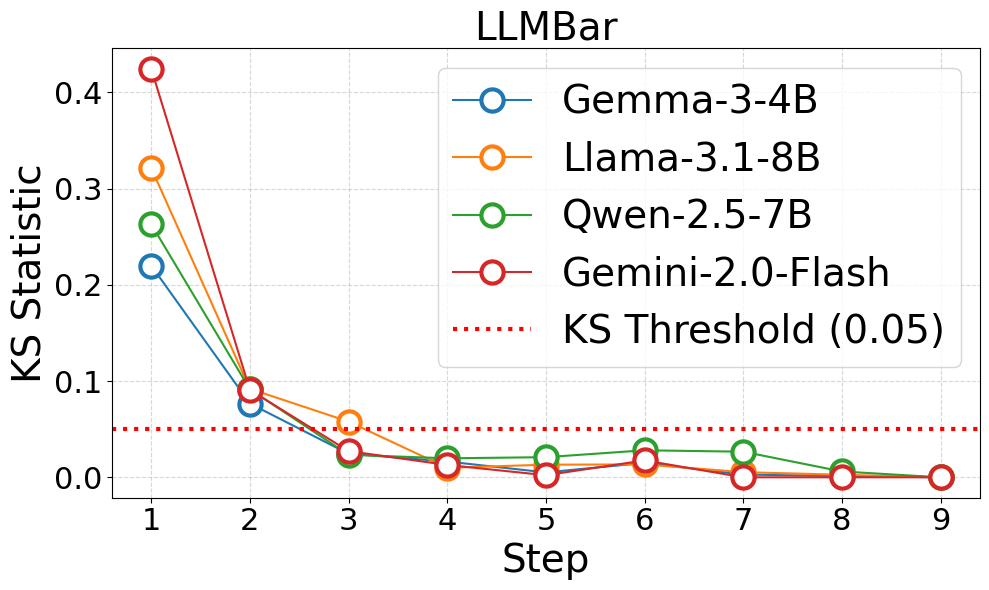

Fit Result for Gemma-3-4B: [{'w': 0.2770864498002129, 'alpha1': 2.387716270095728, 'beta1': 1e-09, 'alpha2': 0.2132638205061961, 'beta2': 0.2967207133510482, 'log_likelihood': -1887.6113720350302, 'n_iter': 7, 'restart': 1, 'chi_square_stat': 12492.47325720049, 'p_value': 0.0, 'round_number': 9}, {'w': 0.5674466114201872, 'alpha1': 3.8419894583127676, 'beta1': 0.030909199792727077, 'alpha2': 0.03780738663705191, 'beta2': 0.6596079106987294, 'log_likelihood': -1174.3006159950987, 'n_iter': 4, 'restart': 1, 'chi_square_stat': 7814.964752239818, 'p_value': 0.0, 'round_number': 9}, {'w': 0.5770248892826573, 'alpha1': 0.4517100289236426, 'beta1': 0.004864303497730242, 'alpha2': 0.006271150903719115, 'beta2': 0.13517178179472455, 'log_likelihood': -955.5345449316571, 'n_iter': 6, 'restart': 1, 'chi_square_stat': 12005.933837421035, 'p_value': 0.0, 'round_number': 9}, {'w': 0.5853744374554345, 'alpha1': 32.51629955878068, 'beta1': 1e-09, 'alpha2': 0.011710096619376555, 'beta2': 1.167176881103

In [1]:
if __name__ == "__main__":
    from pathlib import Path

    from multi_llm_debate.run.llm_bar.utils import (
        compare_llm_bar_response,
        extract_1_2_answer,
        load_llm_bar_dataset,
    )
    from multi_llm_debate.distribution_model.fit_distribution_adaptive_stopping import (
        analyze_distributions_adaptive_stopping,
    )
    from multi_llm_debate.distribution_model.plot_ks_statistics import (
        plot_ks_statistics,
    )
    FIT_METHOD = "em"  # "direct" or "em" optimization approach
    N_RESTARTS = 2  # Number of random restarts for more stable fitting
    ENFORCE_INCREASING = False  # Enforce non-decreasing expected success probability
    MAX_ROUNDS = 10  # or an int
    OUTPUT_DIR = Path("../output/visualizations/llm_bar")
    df = load_llm_bar_dataset(base_path="../")
    task_name = "LLM Bar"
    debate_round_csv_paths = [
        "../data/llm_bar/gemma-3-4b-it(7)/debate_rounds.csv",
        "../data/llm_bar/Llama-3_1-8B-Instruct(7)/debate_rounds.csv",
        "../data/llm_bar/Qwen2_5-7B-Instruct(7)/debate_rounds.csv",
        "../data/llm_bar/gemini-2_0-flash-001(7)/debate_rounds.csv",
    ]
    model_configs = [
        "Gemma-3-4B",
        "Llama-3.1-8B",
        "Qwen-2.5-7B",
        "Gemini-2.0-Flash",
    ]
    fit_results = {}
    ks_statistics_dict = {}
    chi_results = {}
    for i, debate_round_csv_path in enumerate(debate_round_csv_paths):
        _, fit_result, ks_statistic, chi_result = analyze_distributions_adaptive_stopping(
            dataframe=df,
            debates_csv_path=debate_round_csv_path,
            fitting_method=FIT_METHOD,
            max_rounds=MAX_ROUNDS,
            n_restarts=N_RESTARTS,
            verbose=False,
            enforce_increasing_success=ENFORCE_INCREASING,
            extract_func=extract_1_2_answer,
            compare_func=compare_llm_bar_response,
            adaptive_stopping=False,
            ks_threshold=0.05,
            stability_rounds=2,
        )
        fit_results[model_configs[i]] = fit_result
        ks_statistics_dict[model_configs[i]] = ks_statistic
        chi_results[model_configs[i]] = chi_result
    # Plot KS statistics
    plot_ks_statistics(
        ks_stats=ks_statistics_dict,
        round_number=10,
        ks_threshold=0.05,
        output_dir=OUTPUT_DIR,
        title="LLMBar",
    )
    # Print fit results
    for model_config, fit_result in fit_results.items():
        print(f"Fit Result for {model_config}: {fit_result}")
        print("-" * 50)
    # for chi_result in chi_results:
    #     print(f"Chi Result: {chi_result}")
    #     print("-" * 50)

## JudgeBench

Loaded GPT and Claude splits from local paths.


Round 9: 100%|██████████| 620/620 [00:00<00:00, 2203.72task/s]


Plot saved to ../output/visualizations/judge_bench/JudgeBench_ks_statistics.png


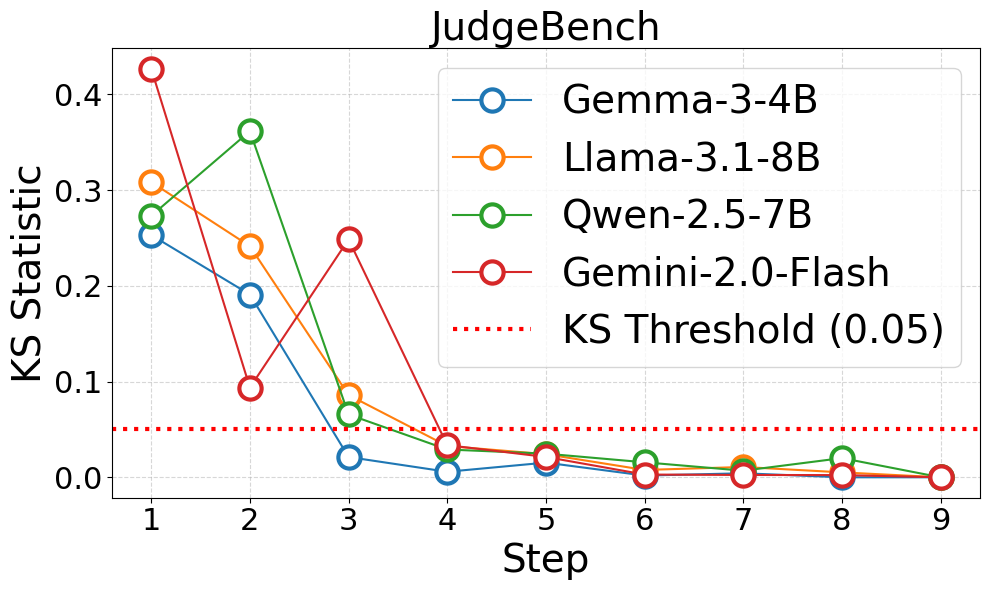

Fit Result for Gemma-3-4B: [{'w': 0.9247398272044741, 'alpha1': 0.28547516316376703, 'beta1': 0.21343484311637562, 'alpha2': 6.662524612830081, 'beta2': 12.962156081720494, 'log_likelihood': -1131.4541158092377, 'n_iter': 12, 'restart': 0, 'chi_square_stat': 961.792618244837, 'p_value': 0.0, 'round_number': 8}, {'w': 0.5388218418924116, 'alpha1': 18.698137309574474, 'beta1': 0.13136489086906383, 'alpha2': 0.05409638206464217, 'beta2': 0.8358504711388667, 'log_likelihood': -649.8987258985235, 'n_iter': 3, 'restart': 1, 'chi_square_stat': 3890.6046042670914, 'p_value': 0.0, 'round_number': 8}, {'w': 0.5789609223443621, 'alpha1': 0.5406771631702693, 'beta1': 0.011071304982813886, 'alpha2': 0.0016996675593768133, 'beta2': 1.487883936417189, 'log_likelihood': -500.18977278668876, 'n_iter': 4, 'restart': 1, 'chi_square_stat': 3233.2876563383625, 'p_value': 0.0, 'round_number': 8}, {'w': 0.14992343862804725, 'alpha1': 0.3849100679277466, 'beta1': 0.019887534771367156, 'alpha2': 1e-09, 'beta2'

In [2]:
if __name__ == "__main__":
    from pathlib import Path

    from multi_llm_debate.run.judge_bench.utils import (
        compare_judge_bench_response,
        extract_caption_a_b_answer,
        load_judge_bench_dataset,
    )
    from multi_llm_debate.distribution_model.fit_distribution_adaptive_stopping import (
        analyze_distributions_adaptive_stopping,
    )
    from multi_llm_debate.distribution_model.plot_ks_statistics import (
        plot_ks_statistics,
    )
    FIT_METHOD = "em"  # "direct" or "em" optimization approach
    N_RESTARTS = 2  # Number of random restarts for more stable fitting
    ENFORCE_INCREASING = False  # Enforce non-decreasing expected success probability
    MAX_ROUNDS = 10  # or an int
    OUTPUT_DIR = Path("../output/visualizations/judge_bench")
    df = load_judge_bench_dataset(base_path="../")
    task_name = "JudgeBench"
    debate_round_csv_paths = [
        "../data/judge_bench/gemma-3-4b-it(7)/debate_rounds.csv",
        "../data/judge_bench/Llama-3_1-8B-Instruct(7)/debate_rounds.csv",
        "../data/judge_bench/Qwen2_5-7B-Instruct(7)/debate_rounds.csv",
        "../data/judge_bench/gemini-2_0-flash-001(7)/debate_rounds.csv",
    ]
    model_configs = [
        "Gemma-3-4B",
        "Llama-3.1-8B",
        "Qwen-2.5-7B",
        "Gemini-2.0-Flash",
    ]
    fit_results = {}
    ks_statistics_dict = {}
    chi_results = {}
    for i, debate_round_csv_path in enumerate(debate_round_csv_paths):
        _, fit_result, ks_statistic, chi_result = analyze_distributions_adaptive_stopping(
            dataframe=df,
            debates_csv_path=debate_round_csv_path,
            fitting_method=FIT_METHOD,
            max_rounds=MAX_ROUNDS,
            n_restarts=N_RESTARTS,
            verbose=False,
            enforce_increasing_success=ENFORCE_INCREASING,
            extract_func=extract_caption_a_b_answer,
            compare_func=compare_judge_bench_response,
            adaptive_stopping=False,
            ks_threshold=0.05,
            stability_rounds=2,
        )
        fit_results[model_configs[i]] = fit_result
        ks_statistics_dict[model_configs[i]] = ks_statistic
        chi_results[model_configs[i]] = chi_result
    # Plot KS statistics
    plot_ks_statistics(
        ks_stats=ks_statistics_dict,
        round_number=10,
        ks_threshold=0.05,
        output_dir=OUTPUT_DIR,
        title="JudgeBench",
    )
    for model_config, fit_result in fit_results.items():
        print(f"Fit Result for {model_config}: {fit_result}")
        print("-" * 50)

## BIG-Bench

Round 6: 100%|██████████| 1000/1000 [00:00<00:00, 2278.15task/s]


Plot saved to ../output/visualizations/big_bench/BIG-Bench_ks_statistics.png


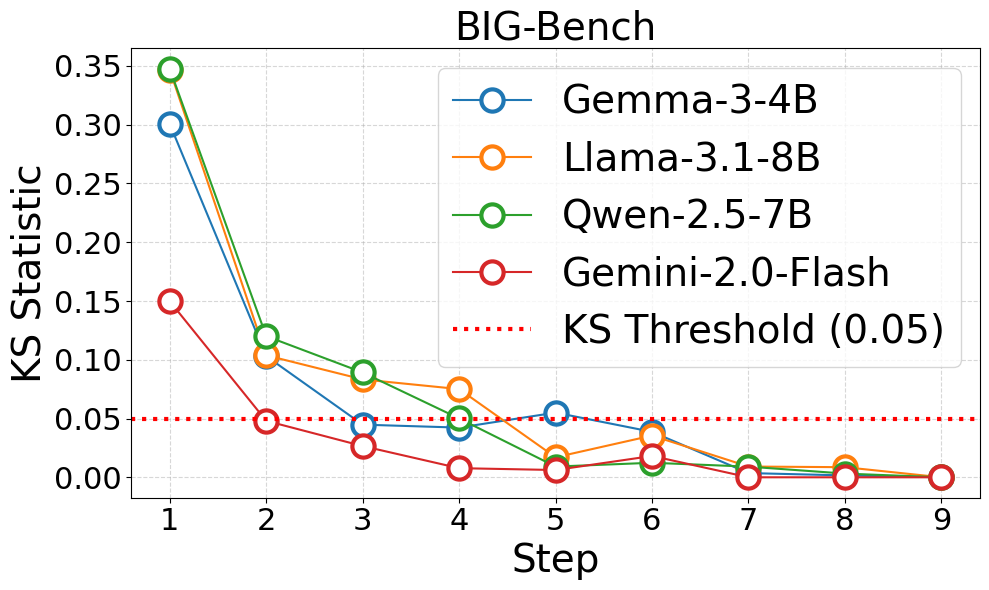

Fit Result for Gemma-3-4B: [{'w': 0.7162253364243121, 'alpha1': 1.4670904041525816, 'beta1': 0.1487940446323759, 'alpha2': 0.35813342175016405, 'beta2': 1.7563163169747287, 'log_likelihood': -1529.89005360834, 'n_iter': 4, 'restart': 1, 'chi_square_stat': 4061.843648682484, 'p_value': 0.0, 'round_number': 9}, {'w': 0.7709102482294654, 'alpha1': 0.3528882696149793, 'beta1': 0.03139112086180724, 'alpha2': 0.04429709338700892, 'beta2': 0.955417566118219, 'log_likelihood': -1019.1316861253101, 'n_iter': 5, 'restart': 1, 'chi_square_stat': 9841.288455220465, 'p_value': 0.0, 'round_number': 9}, {'w': 0.6986132143638659, 'alpha1': 0.7666812465479254, 'beta1': 0.0034218442919559957, 'alpha2': 0.04055733386634633, 'beta2': 0.7370418117065277, 'log_likelihood': -795.651572243625, 'n_iter': 5, 'restart': 1, 'chi_square_stat': 14513.072680211697, 'p_value': 0.0, 'round_number': 9}, {'w': 0.7030347917990858, 'alpha1': 13.206726106762032, 'beta1': 1e-09, 'alpha2': 0.014303883997816456, 'beta2': 0.82

In [3]:

if __name__ == "__main__":
    from pathlib import Path

    from multi_llm_debate.run.big_bench.utils import (
        compare_big_bench_response,
        extract_0_1_answer,
        load_big_bench_dataset,
    )
    from multi_llm_debate.distribution_model.fit_distribution_adaptive_stopping import (
        analyze_distributions_adaptive_stopping,
    )
    from multi_llm_debate.distribution_model.plot_ks_statistics import (
        plot_ks_statistics,
    )
    FIT_METHOD = "em"  # "direct" or "em" optimization approach
    N_RESTARTS = 2  # Number of random restarts for more stable fitting
    ENFORCE_INCREASING = False  # Enforce non-decreasing expected success probability
    MAX_ROUNDS = 10  # or an int
    OUTPUT_DIR = Path("../output/visualizations/big_bench")
    df = load_big_bench_dataset(base_path="../")
    task_name = "BIG-Bench"
    debate_round_csv_paths = [
        "../data/big_bench/gemma-3-4b-it(7)/debate_rounds.csv",
        "../data/big_bench/Llama-3_1-8B-Instruct(7)/debate_rounds.csv",
        "../data/big_bench/Qwen2_5-7B-Instruct(7)/debate_rounds.csv",
        "../data/big_bench/gemini-2_0-flash-001(7)/debate_rounds.csv",
    ]
    model_configs = [
        "Gemma-3-4B",
        "Llama-3.1-8B",
        "Qwen-2.5-7B",
        "Gemini-2.0-Flash",
    ]
    ks_statistics_dict = {}
    chi_results = {}
    fit_results = {}

    for i, debate_round_csv_path in enumerate(debate_round_csv_paths):
        _, fit_result, ks_statistic, chi_result = analyze_distributions_adaptive_stopping(
            dataframe=df,
            debates_csv_path=debate_round_csv_path,
            fitting_method=FIT_METHOD,
            max_rounds=MAX_ROUNDS,
            n_restarts=N_RESTARTS,
            verbose=False,
            enforce_increasing_success=ENFORCE_INCREASING,
            extract_func=extract_0_1_answer,
            compare_func=compare_big_bench_response,
            adaptive_stopping=False,
            ks_threshold=0.05,
            stability_rounds=2,
        )
        ks_statistics_dict[model_configs[i]] = ks_statistic
        chi_results[model_configs[i]] = chi_result
        fit_results[model_configs[i]] = fit_result
    # Plot KS statistics
    plot_ks_statistics(
        ks_stats=ks_statistics_dict,
        round_number=10,
        ks_threshold=0.05,
        output_dir=OUTPUT_DIR,
        title="BIG-Bench",
    )
    for model_config, fit_result in fit_results.items():
        print(f"Fit Result for {model_config}: {fit_result}")
        print("-" * 50)

## TruthfulQA

Round 9: 100%|██████████| 817/817 [00:00<00:00, 2270.01task/s]


Plot saved to ../output/visualizations/truthful_qa/TruthfulQA_ks_statistics.png


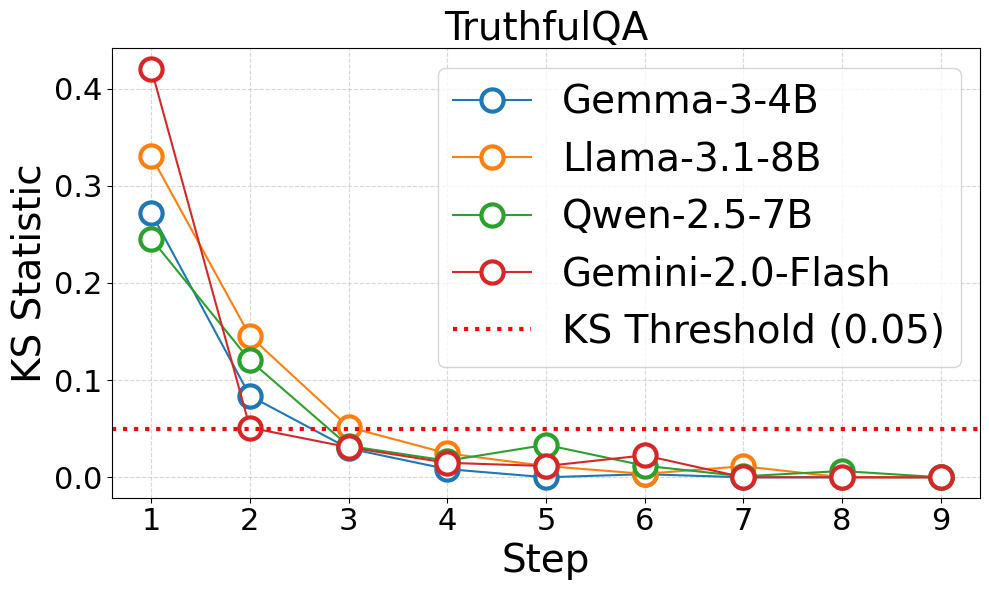

Fit Result for Gemma-3-4B: [{'w': 0.4141774522139004, 'alpha1': 0.5339490365279664, 'beta1': 0.1447837965654303, 'alpha2': 0.10650157736427718, 'beta2': 0.6917127462030943, 'log_likelihood': -1275.5590149407788, 'n_iter': 4, 'restart': 0, 'chi_square_stat': 2817.779294604539, 'p_value': 0.0, 'round_number': 7}, {'w': 0.46837650709808254, 'alpha1': 0.3218000163944916, 'beta1': 0.041711964635790647, 'alpha2': 1e-09, 'beta2': 1.7396804639775296, 'log_likelihood': -792.394581015744, 'n_iter': 4, 'restart': 1, 'chi_square_stat': 18314.117094875506, 'p_value': 0.0, 'round_number': 7}, {'w': 0.39910165613455906, 'alpha1': 1.4487451908014977, 'beta1': 1e-09, 'alpha2': 0.008993795351792544, 'beta2': 0.379201992290022, 'log_likelihood': -646.100537791533, 'n_iter': 3, 'restart': 1, 'chi_square_stat': 5701.635077226458, 'p_value': 0.0, 'round_number': 7}, {'w': 0.4162299556128025, 'alpha1': 1.5848140807889903, 'beta1': 0.004582236003616633, 'alpha2': 1e-09, 'beta2': 2.2276442134045173, 'log_likel

In [4]:

if __name__ == "__main__":
    from pathlib import Path

    from multi_llm_debate.run.truthful_qa.utils import (
        compare_truthful_qa_response,
        extract_caption_a_b_c_answer,
        load_truthful_qa_dataset,
    )
    from multi_llm_debate.distribution_model.fit_distribution_adaptive_stopping import (
        analyze_distributions_adaptive_stopping,
    )
    from multi_llm_debate.distribution_model.plot_ks_statistics import (
        plot_ks_statistics,
    )
    FIT_METHOD = "em"  # "direct" or "em" optimization approach
    N_RESTARTS = 2  # Number of random restarts for more stable fitting
    ENFORCE_INCREASING = False  # Enforce non-decreasing expected success probability
    MAX_ROUNDS = 10  # or an int
    OUTPUT_DIR = Path("../output/visualizations/truthful_qa")
    df = load_truthful_qa_dataset(base_path="../")
    task_name = "TruthfulQA"
    debate_round_csv_paths = [
        "../data/truthful_qa/gemma-3-4b-it(7)/debate_rounds.csv",
        "../data/truthful_qa/Llama-3_1-8B-Instruct(7)/debate_rounds.csv",
        "../data/truthful_qa/Qwen2_5-7B-Instruct(7)/debate_rounds.csv",
        "../data/truthful_qa/gemini-2_0-flash-001(7)/debate_rounds.csv",
    ]
    model_configs = [
        "Gemma-3-4B",
        "Llama-3.1-8B",
        "Qwen-2.5-7B",
        "Gemini-2.0-Flash",
    ]
    ks_statistics_dict = {}
    chi_results = {}
    fit_results = {}
    for i, debate_round_csv_path in enumerate(debate_round_csv_paths):
        _, fit_result, ks_statistic, chi_result = analyze_distributions_adaptive_stopping(
            dataframe=df,
            debates_csv_path=debate_round_csv_path,
            fitting_method=FIT_METHOD,
            max_rounds=MAX_ROUNDS,
            n_restarts=N_RESTARTS,
            verbose=False,
            enforce_increasing_success=ENFORCE_INCREASING,
            extract_func=extract_caption_a_b_c_answer,
            compare_func=compare_truthful_qa_response,
            adaptive_stopping=False,
            ks_threshold=0.05,
            stability_rounds=2,
        )
        ks_statistics_dict[model_configs[i]] = ks_statistic
        chi_results[model_configs[i]] = chi_result
        fit_results[model_configs[i]] = fit_result
    # Plot KS statistics
    plot_ks_statistics(
        ks_stats=ks_statistics_dict,
        round_number=10,
        ks_threshold=0.05,
        output_dir=OUTPUT_DIR,
        title="TruthfulQA",
    )
    for model_config, fit_result in fit_results.items():
        print(f"Fit Result for {model_config}: {fit_result}")
        print("-" * 50)

## MLLM-Judge

Round 7: 100%|██████████| 800/800 [00:00<00:00, 2036.94task/s]


Plot saved to ../output/visualizations/mllm_judge/MLLM-Judge_ks_statistics.png


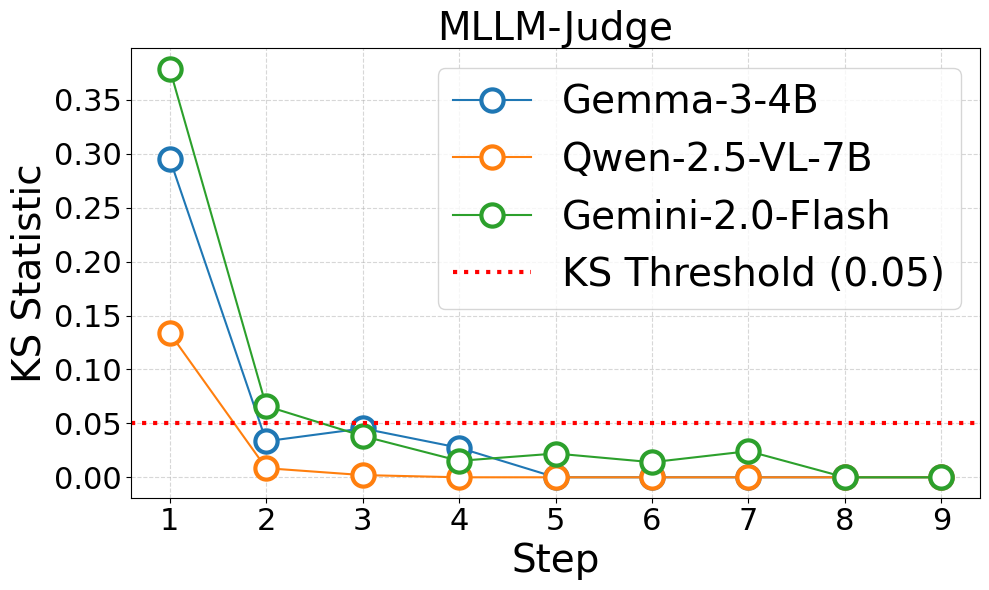

Fit Result for Gemma-3-4B: [{'w': 0.5514177780750061, 'alpha1': 2.3077213995901626, 'beta1': 0.11406838430390454, 'alpha2': 0.20447925187630306, 'beta2': 0.8628662377093427, 'log_likelihood': -1205.5831464811806, 'n_iter': 3, 'restart': 1, 'chi_square_stat': 2835.9884981588702, 'p_value': 0.0, 'round_number': 5}, {'w': 0.6399890226929723, 'alpha1': 0.42146207229940413, 'beta1': 0.011152908789335312, 'alpha2': 0.007255405979046665, 'beta2': 2.2921326190229143, 'log_likelihood': -654.0964079022059, 'n_iter': 4, 'restart': 1, 'chi_square_stat': 4233.674540584929, 'p_value': 0.0, 'round_number': 5}, {'w': 0.6275064957876, 'alpha1': 5.415468415709371, 'beta1': 0.0045297684080230945, 'alpha2': 0.052208249627789825, 'beta2': 51.60740084189797, 'log_likelihood': -555.3516416022862, 'n_iter': 4, 'restart': 1, 'chi_square_stat': 1510.1432503739436, 'p_value': nan, 'round_number': 5}, {'w': 0.6275000026367046, 'alpha1': 20.46514201430138, 'beta1': 0.0132654466155656, 'alpha2': 1e-09, 'beta2': 3.5

In [5]:

if __name__ == "__main__":
    from pathlib import Path

    from multi_llm_debate.run.mllm_judge_pair.utils import (
        extract_caption_a_b_answer,
        compare_mllm_judge_pairs_response,
        load_mllm_judge_pairs,
    )
    from multi_llm_debate.distribution_model.fit_distribution_adaptive_stopping import (
        analyze_distributions_adaptive_stopping,
    )
    from multi_llm_debate.distribution_model.plot_ks_statistics import (
        plot_ks_statistics,
    )
    FIT_METHOD = "em"  # "direct" or "em" optimization approach
    N_RESTARTS = 2  # Number of random restarts for more stable fitting
    ENFORCE_INCREASING = False  # Enforce non-decreasing expected success probability
    MAX_ROUNDS = 10  # or an int
    OUTPUT_DIR = Path("../output/visualizations/mllm_judge")
    df = load_mllm_judge_pairs(base_path="../")
    task_name = "MLLM-Judge"
    debate_round_csv_paths = [
        "../data/mllm_judge_pair/gemma-3-4b-it(7)/debate_rounds.csv",
        "../data/mllm_judge_pair/Qwen2_5-VL-7B-Instruct(7)/debate_rounds.csv",
        "../data/mllm_judge_pair/gemini-2_0-flash-001(7)/debate_rounds.csv",
    ]
    model_configs = [
        "Gemma-3-4B",
        "Qwen-2.5-VL-7B",
        "Gemini-2.0-Flash",
    ]
    ks_statistics_dict = {}
    chi_results = {}
    fit_results = {}
    for i, debate_round_csv_path in enumerate(debate_round_csv_paths):
        _, fit_result, ks_statistic, chi_result = analyze_distributions_adaptive_stopping(
            dataframe=df,
            debates_csv_path=debate_round_csv_path,
            fitting_method=FIT_METHOD,
            max_rounds=MAX_ROUNDS,
            n_restarts=N_RESTARTS,
            verbose=False,
            enforce_increasing_success=ENFORCE_INCREASING,
            extract_func=extract_caption_a_b_answer,
            compare_func=compare_mllm_judge_pairs_response,
            adaptive_stopping=False,
            ks_threshold=0.05,
            stability_rounds=2,
        )
        ks_statistics_dict[model_configs[i]] = ks_statistic
        chi_results[model_configs[i]] = chi_result
        fit_results[model_configs[i]] = fit_result
    # Plot KS statistics
    plot_ks_statistics(
        ks_stats=ks_statistics_dict,
        round_number=10,
        ks_threshold=0.05,
        output_dir=OUTPUT_DIR,
        title="MLLM-Judge",
    )
    for model_config, fit_result in fit_results.items():
        print(f"Fit Result for {model_config}: {fit_result}")
        print("-" * 50)

## JudgeAnything

Round 9: 100%|██████████| 133/133 [00:00<00:00, 1939.11task/s]


Plot saved to ../output/visualizations/judge_anything/JudgeAnything_ks_statistics.png


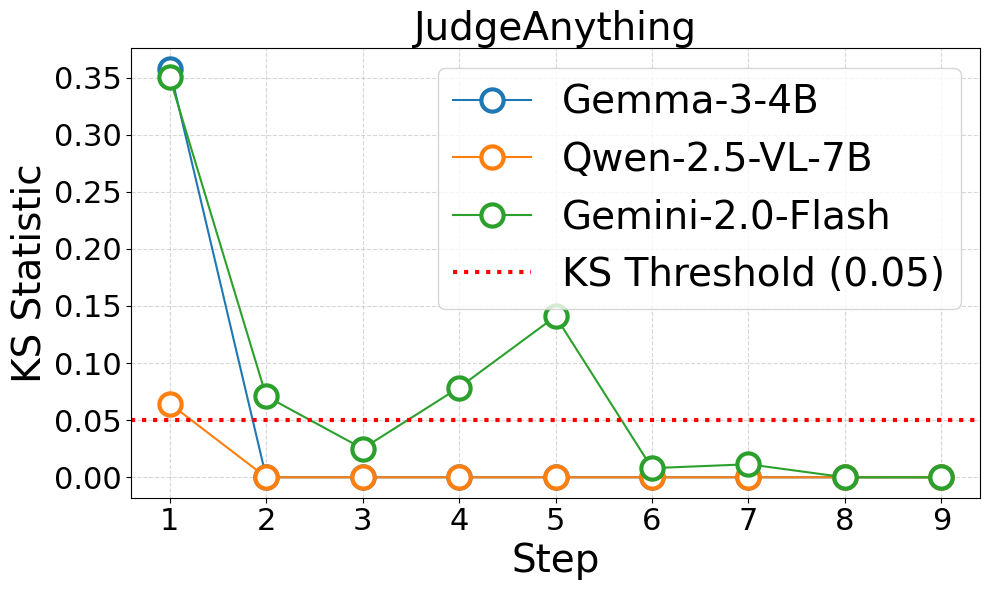

Fit Result for Gemma-3-4B: [{'w': 0.8541325909657632, 'alpha1': 3.2542314283252636, 'beta1': 0.10264631163053335, 'alpha2': 0.5088035612249845, 'beta2': 10.583845922725294, 'log_likelihood': -125.45191443063106, 'n_iter': 3, 'restart': 1, 'chi_square_stat': 1243.8101247951029, 'p_value': 0.0, 'round_number': 2}, {'w': 0.8496240599515735, 'alpha1': 34.120518132011426, 'beta1': 1e-09, 'alpha2': 1e-09, 'beta2': 0.3481027431984343, 'log_likelihood': -56.30696516112111, 'n_iter': 2, 'restart': 0, 'chi_square_stat': 1012.5659733227404, 'p_value': nan, 'round_number': 2}]
--------------------------------------------------
Fit Result for Qwen-2.5-VL-7B: [{'w': 0.6482701859704163, 'alpha1': 0.039700031165883894, 'beta1': 1e-09, 'alpha2': 0.033922868386053434, 'beta2': 0.36673013996609216, 'log_likelihood': -109.52816761327472, 'n_iter': 6, 'restart': 0, 'chi_square_stat': 2852.2614725060726, 'p_value': nan, 'round_number': 2}, {'w': 0.6766917293216009, 'alpha1': 15.747158221040477, 'beta1': 1e-

In [7]:
if __name__ == "__main__":
    from pathlib import Path

    from multi_llm_debate.run.judge_anything_pair.utils import (
        extract_caption_a_b_answer,
        compare_judge_anything_pairs_response,
        load_judge_anything_pairs_dataset,
    )
    from multi_llm_debate.distribution_model.fit_distribution_adaptive_stopping import (
        analyze_distributions_adaptive_stopping,
    )
    from multi_llm_debate.distribution_model.plot_ks_statistics import (
        plot_ks_statistics,
    )
    FIT_METHOD = "em"  # "direct" or "em" optimization approach
    N_RESTARTS = 2  # Number of random restarts for more stable fitting
    ENFORCE_INCREASING = False  # Enforce non-decreasing expected success probability
    MAX_ROUNDS = 10  # or an int
    OUTPUT_DIR = Path("../output/visualizations/judge_anything")
    df = load_judge_anything_pairs_dataset(base_path="../")
    task_name = "JudgeAnything"
    debate_round_csv_paths = [
        "../data/judge_anything_pair/gemma-3-4b-it(7)/debate_rounds.csv",
        "../data/judge_anything_pair/Qwen2_5-VL-7B-Instruct(7)/debate_rounds.csv",
        "../data/judge_anything_pair/gemini-2_0-flash-001(7)/debate_rounds.csv",
    ]
    model_configs = [
        "Gemma-3-4B",
        "Qwen-2.5-VL-7B",
        "Gemini-2.0-Flash",
    ]
    ks_statistics_dict = {}
    chi_results = {}
    fit_results = {}
    for i, debate_round_csv_path in enumerate(debate_round_csv_paths):
        _, fit_result, ks_statistic, chi_result = analyze_distributions_adaptive_stopping(
            dataframe=df,
            debates_csv_path=debate_round_csv_path,
            fitting_method=FIT_METHOD,
            max_rounds=MAX_ROUNDS,
            n_restarts=N_RESTARTS,
            verbose=False,
            enforce_increasing_success=ENFORCE_INCREASING,
            extract_func=extract_caption_a_b_answer,
            compare_func=compare_judge_anything_pairs_response,
            adaptive_stopping=False,
            ks_threshold=0.05,
            stability_rounds=2,
        )
        ks_statistics_dict[model_configs[i]] = ks_statistic
        chi_results[model_configs[i]] = chi_result
        fit_results[model_configs[i]] = fit_result
    # Plot KS statistics
    plot_ks_statistics(
        ks_stats=ks_statistics_dict,
        round_number=10,
        ks_threshold=0.05,
        output_dir=OUTPUT_DIR,
        title="JudgeAnything",
    )
    for model_config, fit_result in fit_results.items():
        print(f"Fit Result for {model_config}: {fit_result}")
        print("-" * 50)

Checking if dataset path exists: ../datasets/JudgeBench
Path exists: True
Loaded GPT and Claude splits from local paths using datasets library.


Round 2: 100%|██████████| 618/618 [00:00<00:00, 2085.66task/s]


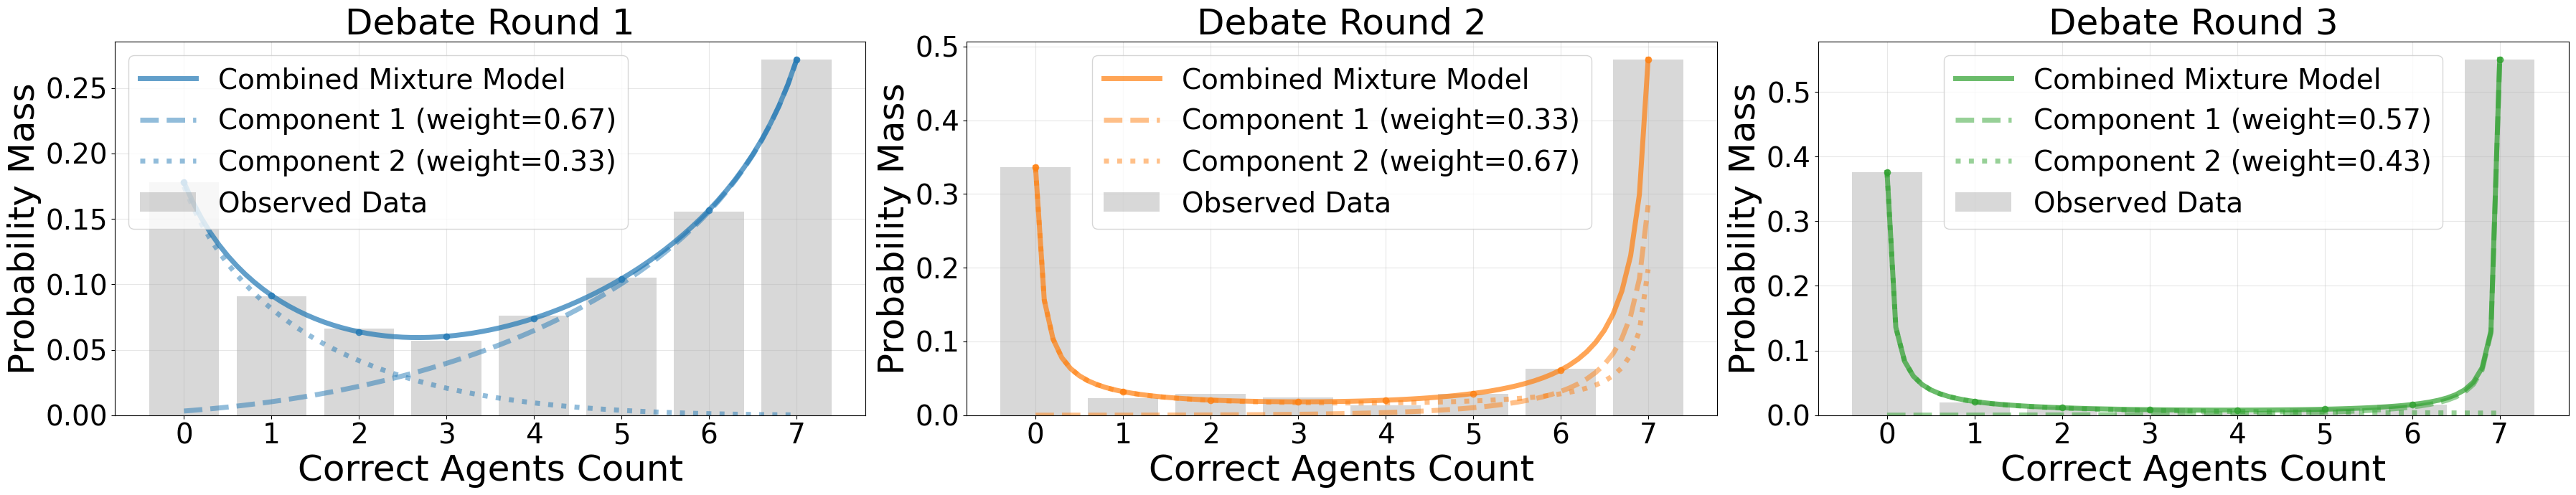

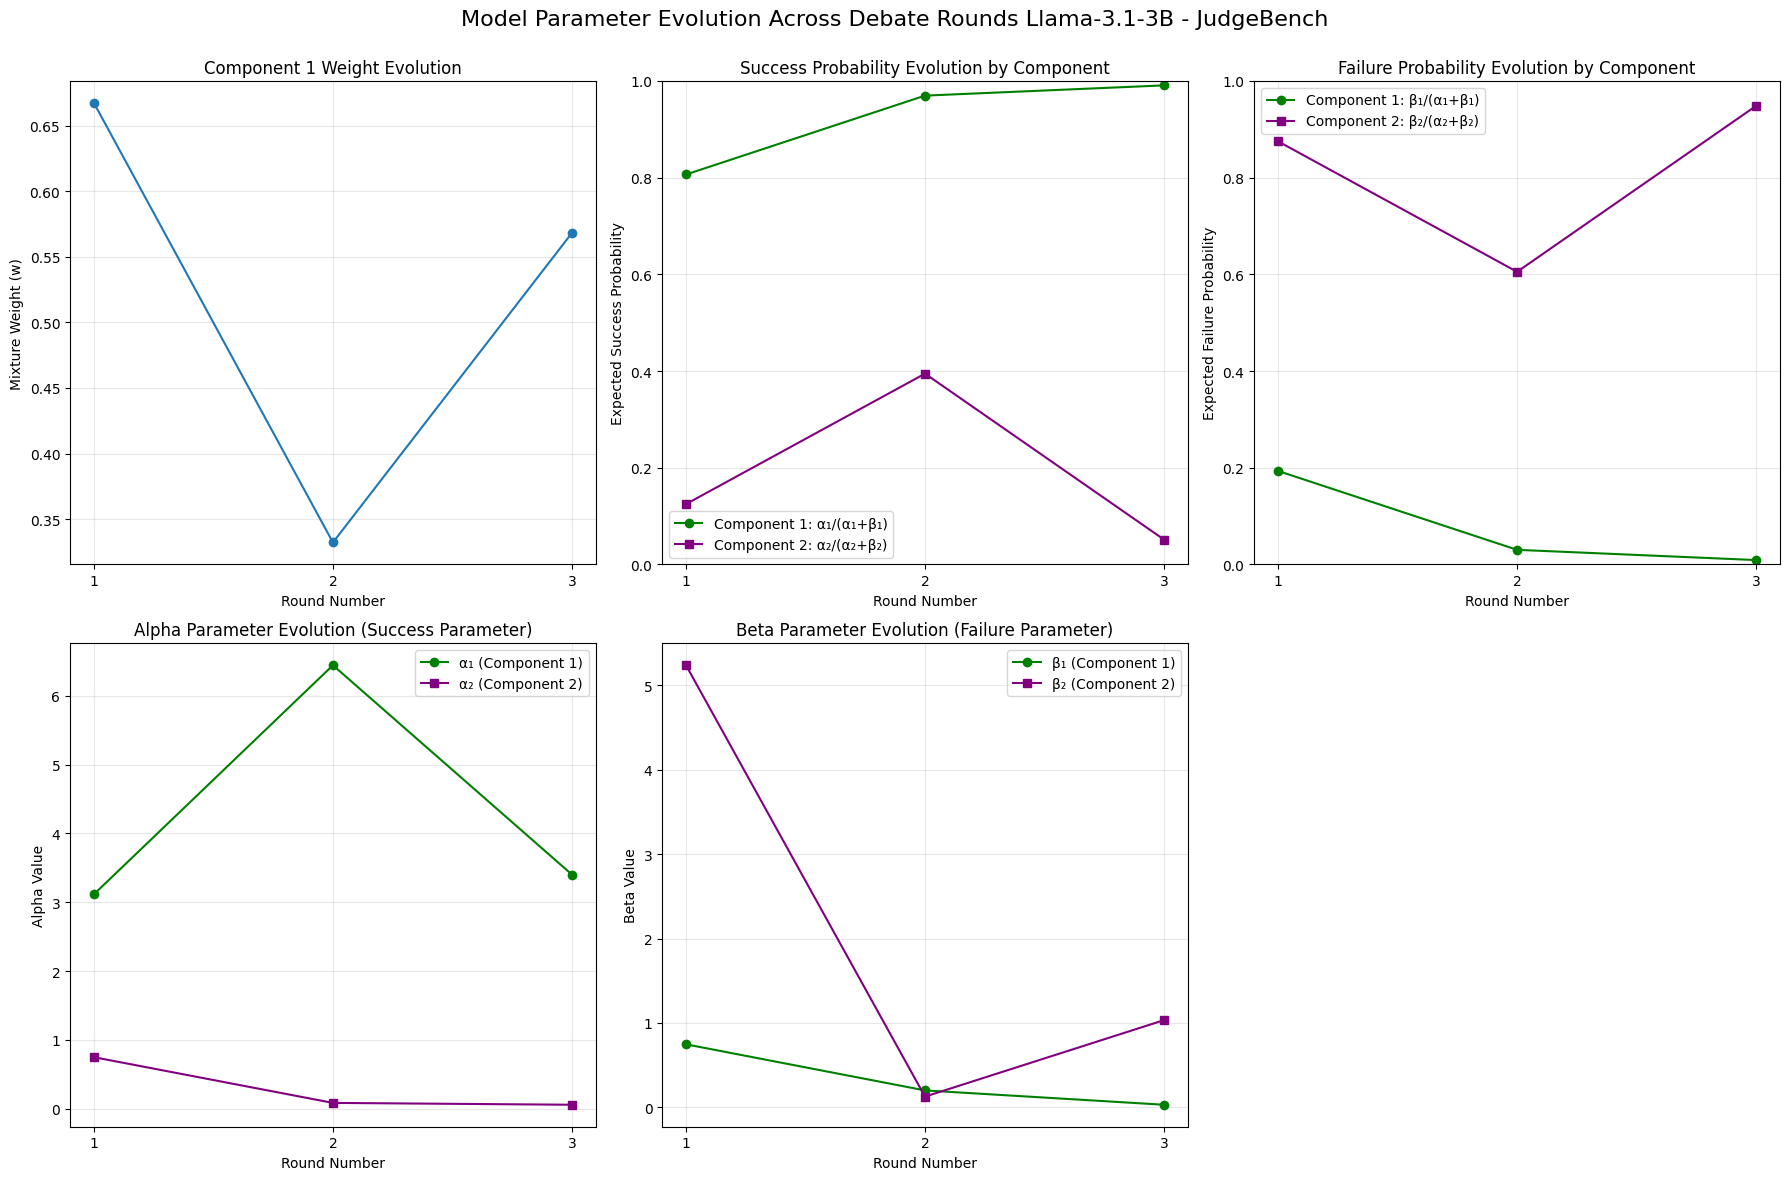

In [2]:
if __name__ == "__main__":
    from pathlib import Path

    from multi_llm_debate.run.judge_bench.utils import (
        compare_judge_bench_response,
        extract_caption_a_b_answer,
        load_judge_bench_dataset,
    )
    from multi_llm_debate.distribution_model.visualize_model import run_visualization

    FIT_METHOD = "em"  # "direct" or "em" optimization approach
    N_RESTARTS = 2  # Number of random restarts for more stable fitting
    ENFORCE_INCREASING = False  # Enforce non-decreasing expected success probability
    MAX_ROUNDS = 3  # or an int

    # Analysis settings
    OUTPUT_DIR = Path("../output/visualizations/judge_bench")
    task_name = "JudgeBench"
    df = load_judge_bench_dataset(base_path="../")
    run_visualization(
        dataframe=df,
        debates_csv_path=Path(
            "../notebooks/debate_rounds.csv"
        ),
        output_dir=OUTPUT_DIR,
        max_rounds=MAX_ROUNDS,
        fitting_method=FIT_METHOD,
        n_restarts=N_RESTARTS,
        verbose=False,
        enforce_increasing_success=ENFORCE_INCREASING,
        extract_func=extract_caption_a_b_answer,
        compare_func=compare_judge_bench_response,
        model_config="Llama-3.1-3B",
        row_number=1,
        task_name=task_name,
        title="Distribution Evolution on JudgeBench Dataset for Llama-3.1-8B",
    )
    # run_visualization(
    #     answers_csv_path=Path("../output/judge_bench/processed_data.csv"),
    #     debates_csv_path=Path(
    #         "../data/judge_bench/Qwen2_5-3B-Instruct(11)/debate_rounds.csv"
    #     ),
    #     output_dir=OUTPUT_DIR,
    #     max_rounds=MAX_ROUNDS,
    #     fitting_method=FIT_METHOD,
    #     n_restarts=N_RESTARTS,
    #     verbose=False,
    #     enforce_increasing_success=ENFORCE_INCREASING,
    #     extract_func=extract_caption_a_b_answer,
    #     compare_func=compare_judge_bench_response,
    #     model_config="Qwen2_5-3B-Instruct(11)",
    #     row_number=2,
    #     task_name=task_name,
    # )
    # run_visualization(
    #     answers_csv_path=Path("../output/judge_bench/processed_data.csv"),
    #     debates_csv_path=Path(
    #         "../data/judge_bench/Llama-3_1-8B-Instruct(11)/debate_rounds.csv"
    #     ),
    #     output_dir=OUTPUT_DIR,
    #     max_rounds=MAX_ROUNDS,
    #     fitting_method=FIT_METHOD,
    #     n_restarts=N_RESTARTS,
    #     verbose=False,
    #     enforce_increasing_success=ENFORCE_INCREASING,
    #     extract_func=extract_caption_a_b_answer,
    #     compare_func=compare_judge_bench_response,
    #     model_config="Llama-3_1-8B-Instruct(11)",
    #     row_number=2,
    #     task_name=task_name,
    # )
    # run_visualization(
    #     answers_csv_path=Path("../output/judge_bench/processed_data.csv"),
    #     debates_csv_path=Path(
    #         "../data/judge_bench/Qwen2_5-7B-Instruct(11)/debate_rounds.csv"
    #     ),
    #     output_dir=OUTPUT_DIR,
    #     max_rounds=MAX_ROUNDS,
    #     fitting_method=FIT_METHOD,
    #     n_restarts=N_RESTARTS,
    #     verbose=False,
    #     enforce_increasing_success=ENFORCE_INCREASING,
    #     extract_func=extract_caption_a_b_answer,
    #     compare_func=compare_judge_bench_response,
    #     model_config="Qwen2_5-7B-Instruct(11)",
    #     row_number=2,
    #     task_name=task_name,
    # )
    # run_visualization(
    #     answers_csv_path=Path("../output/judge_bench/processed_data.csv"),
    #     debates_csv_path=Path(
    #         "../data/judge_bench/Llama-3_1-8B-Instruct(6)+Qwen2_5-7B-Instruct(5)/debate_rounds.csv"
    #     ),
    #     output_dir=OUTPUT_DIR,
    #     max_rounds=MAX_ROUNDS,
    #     fitting_method=FIT_METHOD,
    #     n_restarts=N_RESTARTS,
    #     verbose=False,
    #     enforce_increasing_success=ENFORCE_INCREASING,
    #     extract_func=extract_caption_a_b_answer,
    #     compare_func=compare_judge_bench_response,
    #     model_config="Llama-3_1-8B-Instruct(6)+Qwen2_5-7B-Instruct(5)",
    #     row_number=2,
    #     task_name=task_name,
    # )

In [ ]:
if __name__ == "__main__":
    from pathlib import Path
    from multi_llm_debate.distribution_model.visualize_model import run_visualization
    from multi_llm_debate.run.truthful_qa.utils import (
        extract_caption_a_b_c_answer,
        compare_truthful_qa_response,
    )

    FIT_METHOD = "direct"  # "direct" or "em" optimization approach
    N_RESTARTS = 2  # Number of random restarts for more stable fitting
    ENFORCE_INCREASING = False  # Enforce non-decreasing expected success probability
    MAX_ROUNDS = None  # or an int
    OUTPUT_DIR = Path("../output/visualizations/truthful_qa")
    task_name = "Truthful QA"
    run_visualization(
        answers_csv_path=Path("../output/truthful_qa/processed_data.csv"),
        debates_csv_path=Path(
            "../data/truthful_qa/Llama-3_1-8B-Instruct(11)/debate_rounds.csv"
        ),
        output_dir=OUTPUT_DIR,
        max_rounds=MAX_ROUNDS,
        fitting_method=FIT_METHOD,
        n_restarts=N_RESTARTS,
        verbose=False,
        enforce_increasing_success=ENFORCE_INCREASING,
        extract_func=extract_caption_a_b_c_answer,
        compare_func=compare_truthful_qa_response,
        model_config="Llama-3_1-8B-Instruct(11)",
        row_number=2,
        task_name=task_name,
    )
    run_visualization(
        answers_csv_path=Path("../output/truthful_qa/processed_data.csv"),
        debates_csv_path=Path(
            "../data/truthful_qa/Qwen2_5-7B-Instruct(11)/debate_rounds.csv"
        ),
        output_dir=OUTPUT_DIR,
        max_rounds=MAX_ROUNDS,
        fitting_method=FIT_METHOD,
        n_restarts=N_RESTARTS,
        verbose=False,
        enforce_increasing_success=ENFORCE_INCREASING,
        extract_func=extract_caption_a_b_c_answer,
        compare_func=compare_truthful_qa_response,
        model_config="Qwen2_5-7B-Instruct(11)",
        row_number=2,
        task_name=task_name,
    )

In [ ]:
if __name__ == "__main__":
    from pathlib import Path
    from multi_llm_debate.distribution_model.visualize_model import run_visualization
    from multi_llm_debate.run.llm_bar.utils import (
        extract_1_2_answer,
        compare_llm_bar_response,
    )

    FIT_METHOD = "direct"  # "direct" or "em" optimization approach
    N_RESTARTS = 2  # Number of random restarts for more stable fitting
    ENFORCE_INCREASING = False  # Enforce non-decreasing expected success probability
    MAX_ROUNDS = None  # or an int
    OUTPUT_DIR = Path("../output/visualizations/llm_bar")
    task_name = "LLMBar"
    run_visualization(
        answers_csv_path=Path("../output/llm_bar/processed_data.csv"),
        debates_csv_path=Path(
            "../data/llm_bar/Llama-3_1-8B-Instruct(11)/debate_rounds.csv"
        ),
        output_dir=OUTPUT_DIR,
        max_rounds=MAX_ROUNDS,
        fitting_method=FIT_METHOD,
        n_restarts=N_RESTARTS,
        verbose=True,
        enforce_increasing_success=ENFORCE_INCREASING,
        extract_func=extract_1_2_answer,
        compare_func=compare_llm_bar_response,
        model_config="Llama-3_1-8B-Instruct(11)",
        row_number=2,
        task_name=task_name,
    )
    run_visualization(
        answers_csv_path=Path("../output/llm_bar/processed_data.csv"),
        debates_csv_path=Path(
            "../data/llm_bar/Qwen2_5-7B-Instruct(11)/debate_rounds.csv"
        ),
        output_dir=OUTPUT_DIR,
        max_rounds=MAX_ROUNDS,
        fitting_method=FIT_METHOD,
        n_restarts=N_RESTARTS,
        verbose=True,
        enforce_increasing_success=ENFORCE_INCREASING,
        extract_func=extract_1_2_answer,
        compare_func=compare_llm_bar_response,
        model_config="Qwen2_5-7B-Instruct(11)",
        row_number=2,
        task_name=task_name,
    )

In [ ]:
from typing import Dict
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from multi_llm_debate.analysis.calculate_correct_rate_by_round import (
    calculate_correct_rate_by_round,
)
from multi_llm_debate.analysis.calculate_task_accuracy import analyze_task_accuracy
from multi_llm_debate.run.judge_bench.utils import (
    extract_caption_a_b_answer,
    compare_judge_bench_response,
)

# Maximum round number for your correct_rate_by_round function
MAX_ROUND_NUMBER = 10


def create_plot_absolute_only(
    absolute_by_round: Dict[float, np.ndarray],
    model_name: str,
    task_name: str = "Judge Bench",
) -> None:
    """Plots the absolute accuracy value by round.

    Args:
        absolute_by_round: Dictionary mapping accuracy values to absolute
            metrics by round.
        model_name: Name of the model for the plot title.
        task_name: Name of the task (default is "Judge Bench").
    """
    # Sort the dictionary items by the accuracy value (the dictionary key)
    sorted_items = sorted(absolute_by_round.items(), key=lambda x: x[0])

    # Use a color map for different accuracy values
    accuracy_colors = plt.cm.get_cmap("tab20", len(sorted_items))

    plt.figure(figsize=(10, 6))

    legend_handles = []

    # Plot a line for each unique accuracy value
    for idx, (accuracy, absolute_values) in enumerate(sorted_items):
        # Skip empty arrays or None values
        if absolute_values is None or len(absolute_values) == 0:
            continue

        # Create x-axis values matching the length of absolute_values
        rounds = np.arange(len(absolute_values))

        # Only plot if both rounds and values have the same length
        if len(rounds) > 0 and len(rounds) == len(absolute_values):
            # Get color for this specific accuracy value
            color = accuracy_colors(idx)

            (line,) = plt.plot(
                rounds,
                absolute_values,
                color=color,
                linestyle="-",  # Solid line for absolute
                linewidth=2,
                label=f"Acc={accuracy:.2f} (absolute)",
            )
            legend_handles.append(line)

    # Title and labels
    plt.title(f"Absolute Correct Rate by Round: {model_name} - {task_name}", pad=15)
    plt.xlabel("Round Number")
    plt.ylabel("Correct Rate")
    plt.grid(True, linestyle="--", alpha=0.7)

    if legend_handles:
        plt.legend(handles=legend_handles)

    # Set y-axis limits and ticks
    plt.ylim(0, 1)
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.xticks(range(min(11, MAX_ROUND_NUMBER + 1)))

    plt.tight_layout()
    plt.show()


def process_model_absolute_only(
    model_dir: Path, task_name: str = "Judge Bench"
) -> None:
    """Process model data and create visualizations for the absolute correct rate.

    Args:
        model_dir: Path to the model directory containing debate data.

    This function:
    1) Analyzes accuracy
    2) Calculates absolute correct rates for each unique accuracy value
    3) Plots the results for the absolute correct rate
    """
    model_name = model_dir.name
    print(f"\nProcessing model: {model_name}")

    # 1) Analyze accuracy
    result_df = analyze_task_accuracy(
        model_dir=model_dir,
        dataframe=df,
        extract_func=extract_caption_a_b_answer,
        compare_func=compare_judge_bench_response,
    )

    # 2) Get all unique accuracy values from the result dataframe
    unique_accuracies = result_df["accuracy"].unique()

    # 3) Create a dictionary to store the absolute metric by round for each accuracy
    absolute_by_round = {}

    length = len(result_df)
    # 4) For each unique accuracy value, calculate absolute correct rates by round
    for accuracy in unique_accuracies:
        if accuracy < 0:
            continue

        # Filter tasks by accuracy
        filtered_df = result_df[result_df["accuracy"] == accuracy]

        # Calculate and print the percentage of tasks with this accuracy
        accuracy_percentage = (len(filtered_df) / length) * 100
        print(f"Accuracy = {accuracy:.2f}: {accuracy_percentage:.2f}% of total tasks")

        try:
            # Calculate absolute correct rates for this accuracy
            cr_filtered_df = calculate_correct_rate_by_round(
                filtered_df,
                model_dir,
                max_round_number=MAX_ROUND_NUMBER,
                extract_func=extract_caption_a_b_answer,
                compare_func=compare_judge_bench_response,
            )

            # Check if we have results for the absolute metric
            absolute_rows = cr_filtered_df[cr_filtered_df["metric"] == "absolute"]
            if not absolute_rows.empty:
                absolute_by_round[accuracy] = absolute_rows.iloc[0, 2:].values

        except Exception as e:
            print(f"Error processing accuracy {accuracy}: {e}")
            continue

    # 5 Create the plot for absolute correct rates
    create_plot_absolute_only(absolute_by_round, model_name, task_name)


# ==========================
# 3. MAIN SCRIPT
# ==========================
if __name__ == "__main__":
    from multi_llm_debate.run.judge_bench.utils import load_judge_bench_dataset
    import os

    df = load_judge_bench_dataset(dataset_path="../datasets/JudgeBench")
    os.makedirs("../output/judge_bench", exist_ok=True)
    df_path = Path("../output/judge_bench/processed_data.csv")
    df.to_csv(df_path, index=False)

    OUTPUT_DIR = Path("../output/visualizations/judge_bench")

    process_model_absolute_only(
        Path("../data/judge_bench/Llama-3_2-3B-Instruct(11)"), task_name
    )
    process_model_absolute_only(
        Path("../data/judge_bench/Qwen2_5-3B-Instruct(11)"), task_name
    )
    process_model_absolute_only(
        Path("../data/judge_bench/Llama-3_1-8B-Instruct(11)"), task_name
    )
    process_model_absolute_only(
        Path("../data/judge_bench/Qwen2_5-7B-Instruct(11)"), task_name
    )